## Summary
#### Best Advice for the real world:

**War is peace**
* Fight your war at the boundary so that you can have peace within
* Challenge your clients to reduce the scope of your deliverable
* Define a minimal set of interactions to the outside world

**Ignorance is strength**
* Design dumb modules that only do one thing
* Keep it simple and stupid
* Separation of concerns, modular

**Freedom is slavery**
* Must be disciplined in testing, code review, releases etc.
* Limit the interface of your module (or external commitments)
* Freedom  → possibilities  → complexity  →  unmodifiable code  → slavery

#### Less is more
Sun Tzu (孙子): "the supreme art of quant modeling is to solve problems without coding"

## Errors and floating point computation
#### Absolute and Relative Error
If the true value  a is approximated by  â :
- Absolute error: $â −a$ 
- Relative error: $\frac{â −a}{a}$

#### Sources of error
- Truncation Errors: introduced when exact maths formulae are represented by approximations
  - Convergence error
  - Monte Carlo simulation
  - Numerical integration
  - Truncation and discretization
  - Termination of iterations
- Roundoff Errors: occur because computers have a limited ability to represent numbers
  - Floating Point Number
  - Rounding

### IEEE 754 Floating Point Number Format

The IEEE floating-point number standard is the most widely used standard for representing real numbers on computers.

**Key Components:**

* **Sign bit:** Determines if the number is positive (0) or negative (1).
* **Exponent:** Determines the scale or magnitude of the number.
* **Implicit bit:** An assumed leading bit (usually 1) to maximize precision.
* **Fraction (Mantissa):** The significant bits of the number.

**Value Formula:**

$$\underbrace{\mathtt{*}}_{\text{sign bit}} \quad \underbrace{\mathtt{********}}_{\text{exponent}} \quad \overbrace{\mathtt{1.}}^{\text{implicit}} \quad \underbrace{\mathtt{***********************}}_{\text{fraction}}$$

$$(-1)^{\text{sign}} \times (1 + \text{fraction}) \times 2^{\text{exponent}-p}$$

---

#### 32-bit vs. 64-bit Format

| Format | Sign Bits | Fraction Bits | Exponent Bits | Bias ($p$) | Exponent Range |
| --- | --- | --- | --- | --- | --- |
| **IEEE 754 (32-bit / Single Precision)** | 1 | 23 | 8 | 127 | -126 to 127 |
| **IEEE 754 (64-bit / Double Precision)** | 1 | 52 | 11 | 1023 | -1022 to 1023 |

> **Special Interpretations & Rules:**
> * **Implicit Leading Bit:** There is an implicit leading bit of `1`, and the binary point is placed immediately before the fraction bits.
> * **Reserved Exponents:** An exponent of `0` (all zeros) and the maximum exponent (all ones, e.g., 255 for 32-bit) are reserved for special values like `0`, `NaN` (Not a Number), and `Inf` (Infinity).
> 
> 

### 1. Why do we need the Bias?

In scientific notation, exponents can be positive ($10^3$) or negative ($10^{-3}$). To store this in binary, we have two choices:

1. Use a **sign bit** for the exponent.
2. Use a **bias**.

IEEE 754 chose the **bias** because it makes comparing two floating-point numbers much faster for the CPU.

#### The "Sorting" Trick

If we used a sign bit, the bit pattern for a small number (negative exponent) would look "larger" than a big number (positive exponent) to a simple sorting algorithm. By adding a **Bias** (e.g., **127** for 32-bit), we shift the range:

* **True Exponent -126** becomes **1** in storage ($-126 + 127$).
* **True Exponent 0** becomes **127** in storage ($0 + 127$).
* **True Exponent 127** becomes **254** in storage ($127 + 127$).

Because all stored exponents are now **unsigned integers (uint)** from 1 to 254, the computer can compare two floats just by looking at their bit strings from left to right, without doing complex math.

---

### 2. What is Denormalization?

To save space, IEEE 754 usually assumes there is an **implicit leading 1** (e.g., $1.f \times 2^e$). This is called **Normalization**.

However, as you get closer and closer to zero, you eventually reach the smallest possible normalized number. If you try to go smaller, you hit a "gap" where the math breaks. **Denormalization** (or "Subnormal" numbers) fills that gap.

#### How it works:

When the **Exponent bits are all 0**, the rules change:

1. The implicit leading bit becomes **0** instead of **1** ($0.f$ instead of $1.f$).
2. The exponent is fixed at **-126** (for 32-bit).

This allows the number to "fade out" gracefully toward zero rather than just snapping to absolute zero.

---

### 1. Normalization Example

**Number:** $15.25$

To "normalize" a number, we write it in binary and move the decimal point until there is exactly **one** non-zero digit to the left.

1. **Binary conversion:** $15.25 \rightarrow 1111.01_2$
2. **Move the point:** Shift it 3 places to the left to get $1.11101 \times 2^3$.
3. **Identify Parts:**
* **Sign:** Positive ($0$).
* **Fraction (Mantissa):** The part after the decimal: `11101`. (The leading `1.` is **implicit** and not stored).
* **Exponent:** The true exponent is $3$. We add the bias ($127$) to get the stored value: $3 + 127 = 130$.


4. **Stored Bits:** * `0` (Sign) | `10000010` (Exp: 130) | `11101000000000000000000` (Fraction)

---

### 2. Denormalization Example

**Number:** A very tiny value, like $1.0 \times 2^{-140}$

In 32-bit, the smallest possible "normal" exponent is $-126$ (stored as `00000001`). Anything smaller than that requires **Denormalization**.

1. **The Trigger:** The exponent bits are set to **all zeros** (`00000000`).
2. **The Shift:** Instead of $1.f \times 2^{e-127}$, the formula changes to $0.f \times 2^{-126}$.
3. **Identify Parts:**
* **Sign:** Positive ($0$).
* **Exponent Bits:** All `0`s (This tells the CPU: "Switch to denormal mode!").
* **Implicit Bit:** Becomes **0** instead of 1.
* **Fraction:** To represent $2^{-140}$ using a fixed $2^{-126}$ exponent, we have to shift the fraction bits further right, losing some precision to stay "alive."


4. **Stored Bits:**
* `0` | `00000000` | `00000000000000100000000...`



---

### Comparison Summary

| Feature | Normalized ($15.25$) | Denormalized (Tiny) |
| --- | --- | --- |
| **Binary Form** | $1.11101 \times 2^3$ | $0.00000000000001 \times 2^{-126}$ |
| **Stored Exp Bits** | `10000010` (130) | `00000000` (Zero) |
| **Hidden Bit** | **1** | **0** |
| **Precision** | Full (24 bits effective) | Reduced (bits "fall off" the right side) |

### Why this matters

Denormalization prevents **"Flush to Zero."** Without it, a calculation that results in a tiny number would suddenly hit $0$, causing massive errors in simulations or processing. With denormalization, the number gets slightly less precise but stays "real" for a bit longer.

In [6]:
import pandas as pd
import numpy as np
from bitstring import BitArray

def parts_to_float(sign_value, true_exponent, mantissa_value):
    """
    Reconstructs a floating-point number from its decimal components.
    Formula: (-1)^sign * mantissa * 2^exponent
    """
    # sign_value should be 1 for positive, -1 for negative
    return sign_value * mantissa_value * (2.0 ** true_exponent)

def float_to_parts(value, bit_length=32):
    """
    Decomposes a float into its IEEE 754 components: Sign, Exponent, and Fraction.
    """
    component_offsets = {32: 9, 64: 12} # 1 (sign bit) + exponent bias (8/11)
    fraction_start_index = component_offsets[bit_length]
    
    # Calculate the Exponent Bias: 2^(k-1) - 1
    exponent_bit_count = fraction_start_index - 1
    exponent_bias = 2**(exponent_bit_count - 1) - 1

    # Convert the float to a bit string
    bit_representation = BitArray(float=value, length=bit_length)
    
    # Slice the bit string into its 3 components
    sign_bit = bit_representation[:1]
    exponent_bits = bit_representation[1:fraction_start_index]
    fraction_bits = bit_representation[fraction_start_index:]

    # Calculate Decimal Interpretations
    sign_value = 1 if sign_bit.uint == 0 else -1 # uint = unsigned int
    
    # Exponent: True Exponent = Biased Exponent - Bias
    # If exponent bits are all 0, it's a denormalized number
    if exponent_bits.uint > 0:
        true_exponent = exponent_bits.uint - exponent_bias
        mantissa_value = 1.0 + (fraction_bits.uint / (2**(bit_length - fraction_start_index)))
    else:
        # Denormalized case
        true_exponent = 1 - exponent_bias
        mantissa_value = fraction_bits.uint / (2**(bit_length - fraction_start_index))
    
    # Format for display
    bit_strings = [sign_bit.bin, exponent_bits.bin, fraction_bits.bin]
    decimal_values = [sign_value, true_exponent, mantissa_value]
    
    df = pd.DataFrame(
        [bit_strings, decimal_values], 
        columns=["Sign", "Exp", "Mantissa"], 
        index=['Bits', 'Decimal']
    )
    return df

In [7]:
float_to_parts(15.3, 32)

,Sign,Exp,Mantissa
Bits,0,10000010,11101001100110011001101
Decimal,1,3,1.9125


In [8]:
float_to_parts(-23445.25, 64)

,Sign,Exp,Mantissa
Bits,1,10000001101,0110111001010101000000000000000000000000000000...
Decimal,-1,14,1.430984


#### Range and precision
- The range of floating point number are usually adequate in practice
- the whole universe only have  $10^{80}$ protons
- The machine precision is the more commonly encountered limitation
- machine precision $\epsilon_m$ is the maximum $\epsilon$ that makes  $1+\epsilon=1$

In [16]:
float_to_parts(-0., 32)

,Sign,Exp,Mantissa
Bits,1,00000000,00000000000000000000000
Decimal,-1,-126,0.0


In [17]:
float_to_parts(np.nan, 32)

,Sign,Exp,Mantissa
Bits,0,11111111,10000000000000000000000
Decimal,1,128,1.5


In [18]:
float_to_parts(-np.inf, 32)

,Sign,Exp,Mantissa
Bits,1,11111111,00000000000000000000000
Decimal,-1,128,1.0


In [19]:
float_to_parts(-1e-45, 32)

,Sign,Exp,Mantissa
Bits,1,00000000,00000000000000000000001
Decimal,-1,-126,0.0


In [21]:
# Floating point computing is not exact
a = 1./3
b = a+a+1.-1
c = 2*a
print(a,b,c)
print(b==c, b-c)

0.3333333333333333 0.6666666666666665 0.6666666666666666
False -1.1102230246251565e-16


In [22]:
float_to_parts(b, 64)

,Sign,Exp,Mantissa
Bits,0,01111111110,0101010101010101010101010101010101010101010101...
Decimal,1,-1,1.333333


In [23]:
float_to_parts(c, 64)

,Sign,Exp,Mantissa
Bits,0,01111111110,0101010101010101010101010101010101010101010101...
Decimal,1,-1,1.333333


In [25]:
# Can't handle numbers too large or small
x = 1e-308
print(x, 1.0/x)

y = 1e-309
print(y, 1./y)

1e-308 1e+308
1e-309 inf


In [26]:
# Limited precision
print(1.-1e-16 == 1.)
print(1. + 1e-16 == 1.)

False
True


In [27]:
largeint = 2**32 - 1

print("Integer arithmetic:")
a = math.factorial(30) # in Python's bignum
print("a = ", a)
print("a - {:d} == a ?".format(largeint), (a - largeint) == a)

print("\nFloating point arithmetic:")
b = float(math.factorial(30))
print("b = ", b)
print("b - {:d} == b ?".format(largeint), (b - largeint) == b)

Integer arithmetic:
a =  265252859812191058636308480000000
a - 4294967295 == a ? False

Floating point arithmetic:
b =  2.6525285981219107e+32
b - 4294967295 == b ? True


#### Subtle errors

In [30]:
a = np.arange(0,3. -1., 1.)
print('a', a)
print('a/3', a/3.)

a [0. 1.]
a/3 [0.         0.33333333]


In [31]:
b = np.arange(0,1-1./3, 1./3.)
b

array([0.        , 0.33333333, 0.66666667])

## 1. Avoid Equality Tests

Performing an equality test ($==$) on floating-point numbers is **always** a bad idea for the following reasons:

* **Rounding Errors:** Mathematical equality often fails in code because numbers that should be equal have tiny differences due to how they are stored.
* **Loop Issues:** Using floats for loop conditions often produces **off-by-one errors** or infinite loops because the counter never exactly hits the target value.

### Best Practices:

* **Use Error Bounds:** Always use a "tolerance" or "epsilon" when comparing numbers. In Python, use: `numpy.allclose(a, b)`.
* **Use Integer Loop Counters:** Try to use integer comparisons as the end condition for loops.
* **Exact Arithmetic:** Remember that **integer representation and arithmetic in IEEE 754 is exact**, whereas floating-point arithmetic is an approximation.

---

## 2. Catastrophic Cancellation

A dramatic loss of precision occurs when **two very similar numbers are subtracted**. This is because the leading significant digits cancel each other out, leaving only the "garbage" rounding errors behind.

### Example: Evaluating a function near zero

Consider the following function:

$$f(x) = \frac{1}{x^2}(1 - \cos(x))$$

**Mathematically:**


$$\lim_{x \to 0} f(x) = \frac{1}{2}$$

**In Practice:**
A straightforward implementation of this formula fails spectacularly for very small values of $x$. As $x$ approaches $0$, $\cos(x)$ becomes very close to $1$. Subtracting $\cos(x)$ from $1$ results in **catastrophic cancellation**, leading to a result of $0$ or significant noise instead of $0.5$.

---

### Pro-Tip

To fix the "Catastrophic Cancellation" in the example above, you would use a **Taylor Series expansion** for $\cos(x)$ when $x$ is small to avoid the subtraction entirely.

[-4.0e-08 -3.9e-08 -3.8e-08 -3.7e-08 -3.6e-08] ... [3.5e-08 3.6e-08 3.7e-08 3.8e-08 3.9e-08]


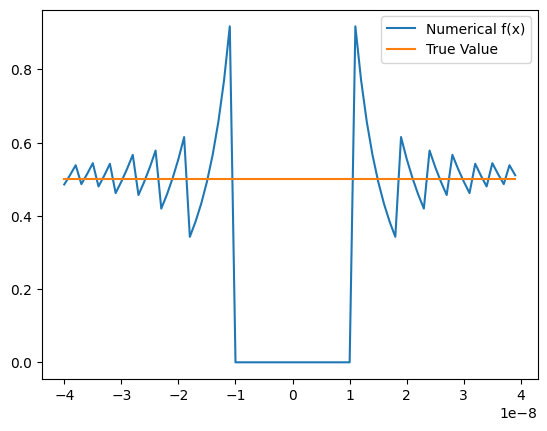

In [36]:
def f(x) :
    return (1.-np.cos(x))/x**2

def g(x) :
    return (np.sin(.5*x)**2*2)/x**2

x = np.arange(-4e-8, 4e-8, 1e-9) # range [a,b) with c increment = arange(a,b,c)
print(x[0:5], '...', x[-5:])
df = pd.DataFrame(np.array([f(x), g(x)]).T, index=x, columns=['Numerical f(x)', 'True Value']);
df.plot();

In [38]:
# How did it happen?
x = 1.1e-8
print("cos({:.16e}) = {:.16f}".format(x, np.cos(x)))
print("1-cos({:.0e}) = {:.16e}".format(x, 1.-np.cos(x)))
print("true value of 1-cos({:.0e}) = {:.16e}".format(x, 2*np.sin(.5*x)**2))

cos(1.0999999999999999e-08) = 0.9999999999999999
1-cos(1e-08) = 1.1102230246251565e-16
true value of 1-cos(1e-08) = 6.0499999999999997e-17


* Dramatic precision loss when subtracting numbers that are very similar
* Most leading significant digits cancel
* The result has much fewer number of significant digits
* Catastrophic cancellation could easily happen in practice
* Deltas are often computed by bump and re-value
* Very small bump sizes should be avoided

### A Real Example in Finance: The CIR Process

The **Cox-Ingersoll-Ross (CIR)** process is widely used in quantitative finance (e.g., for modeling short-term interest rates and in the Heston stochastic volatility model).

**The Stochastic Differential Equation (SDE):**


$$dr_t = \kappa(\mu - r_t)dt + \sigma\sqrt{r_t}dW_t$$

**The Variance of $r_t$ at $t > 0$:**
Given an initial rate $r_0$, the variance is calculated as:


$$Var[r_t | r_0] = r_0 \frac{\sigma^2}{\kappa} (e^{-\kappa t} - e^{-2\kappa t}) + \mu \frac{\sigma^2}{2\kappa} (1 - e^{-\kappa t})^2$$

---

### How Catastrophic Cancellation Arises

Catastrophic cancellation occurs in this formula in two specific places, particularly when **$\kappa$ (the speed of mean reversion)** or **$t$ (time)** are very small.

#### 1. The $(e^{-\kappa t} - e^{-2\kappa t})$ Term

When $\kappa t \approx 0$:

* Both $e^{-\kappa t}$ and $e^{-2\kappa t}$ are incredibly close to **1**.
* You are subtracting two large, nearly identical values.
* As we saw with the $1 - \cos(x)$ example, the significant digits cancel out, leaving only the "floating-point noise" (rounding errors) in the result.

#### 2. The $(1 - e^{-\kappa t})^2$ Term

When $\kappa t \approx 0$:

* $e^{-\kappa t}$ is approximately $0.9999...$
* Calculating $(1 - 0.9999...)$ causes an immediate loss of precision.
* Squaring that "noisy" result compounds the error significantly.

### How Quants Fix This

In professional financial libraries, when $\kappa t$ is smaller than a certain threshold (e.g., $10^{-4}$), they don't use the formula above. Instead, they use a **Taylor Series expansion** of the exponential function:

$$e^{-x} \approx 1 - x + \frac{x^2}{2!} - \frac{x^3}{3!}$$

By substituting this into the $(1 - e^{-\kappa t})$ term, the "1" cancels out mathematically *before* it ever reaches the computer's processor, leaving a stable calculation:


$$(1 - (1 - \kappa t + \dots)) = \kappa t - \dots$$

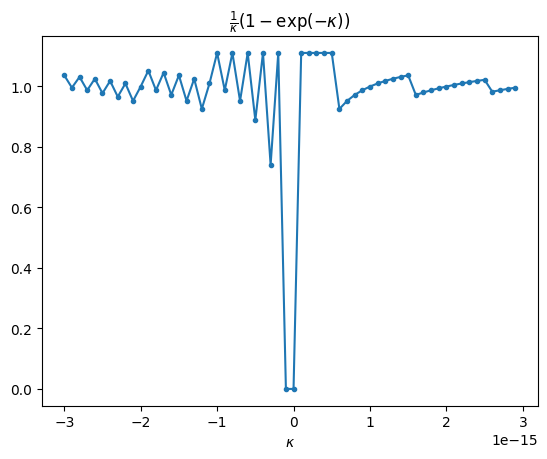

In [42]:
k = np.arange(-3e-8, 3e-8, 1e-9)*1e-7
t = 1
v = (1-np.exp(-k*t))/k

import matplotlib.pyplot as plt
plt.plot(k, v, '.-')
plt.title(r'$\frac{1}{\kappa}(1-\exp(-\kappa))$')
plt.xlabel(r'$\kappa$');

In [53]:
import sympy as sp
sp.init_printing(use_latex = True)

k = sp.symbols("k", positive = True)
e = (1-sp.exp(-k))/k
sp.limit(e, k, 0)

SymPy solves symbolic math by treating variables as **objects** rather than **memory addresses containing numbers**.

In your previous NumPy code, `k` was a 64-bit floating-point number. In SymPy, `k` is a formal mathematical symbol, like a letter in an algebraic equation.

Here is the "behind the scenes" of how SymPy works:

### 1. The Expression Tree

When you type `(1 - sp.exp(-k)) / k`, SymPy doesn't calculate a result. Instead, it builds an **Expression Tree**.

* The root of the tree is a `Division` operation.
* The branches are `Addition` (for the $1 - \dots$ part) and the `Symbol` $k$.
* The leaves are the constants and variables.

By keeping the math in a tree structure, SymPy can rearrange the "branches" using algebraic rules (like factoring or expanding) without ever losing precision to rounding errors.

---

### 2. Rewriting and Simplification

To solve a limit like $\lim_{k \to 0} \frac{1 - e^{-k}}{k}$, SymPy uses several strategies:

* **Taylor Series Expansion:** It replaces $e^{-k}$ with its infinite series representation:

$$1 - k + \frac{k^2}{2!} - \frac{k^3}{3!} + \dots$$


* **Algebraic Cancellation:** It substitutes the series back into the expression:

$$\frac{1 - (1 - k + \frac{k^2}{2!} - \dots)}{k} \rightarrow \frac{k - \frac{k^2}{2!} + \dots}{k} \rightarrow 1 - \frac{k}{2} + \dots$$


* **Evaluation:** It sets $k$ to $0$ in the simplified result, leaving exactly **1**.

---

### 3. Comparison: Numerical vs. Symbolic

| Feature | Numerical (NumPy/IEEE 754) | Symbolic (SymPy) |
| --- | --- | --- |
| **Storage** | Binary bits (Sign, Exp, Fraction) | Objects in an Expression Tree |
| **Precision** | Finite (approx. 15-17 digits) | **Infinite / Exact** |
| **Speed** | Extremely fast (processed by CPU) | Slower (processed by Python logic) |
| **Best For** | Large simulations, Data Science | Calculus, Proofs, Formula derivation |

---

### 4. Why use SymPy in Finance?

In models like **CIR** or **Black-Scholes**, the formulas can become incredibly messy. Quants use SymPy to:

1. **Derive the Greeks** (the derivatives of option prices) automatically.
2. **Check for Catastrophic Cancellation** points by finding limits where the denominator goes to zero.
3. **Generate C++ or Python code** from a simplified symbolic expression.


## Next
### 1. The Optimal "Bump" (Step Size)

When calculating a derivative numerically ($f'(x) \approx \frac{f(x+h)-f(x)}{h}$), you face a tug-of-war between two errors:

* **Truncation Error:** Choosing an $h$ that is too large (the formula is just an approximation).
* **Rounding Error:** Choosing an $h$ that is too small (causing catastrophic cancellation).

The **Optimal Step Size ($h^*$)** occurs when these two errors are equal. For a standard forward difference, this is:


$$h^* = \sqrt{\frac{2f(x)\epsilon_m}{f''(x)}}$$


*Note: Using **Central Difference** is almost always better because its truncation error is much smaller, allowing for a more stable result.*

---

### 2. Condition Number: The "Growth Factor"

The **Condition Number $k(f)$** measures how much an error in your input is amplified in your output.

* **Formula:** $k(f) = \sum_i \left| \frac{x_i}{f} \frac{\partial f}{\partial x_i} \right|$
* **Rule of Thumb:** If the condition number is $10^n$, you expect to lose roughly $n$ decimal digits of accuracy.
* **Well-posed:** Small condition number (e.g., multiplication).
* **Ill-posed:** Large condition number (e.g., subtracting two nearly equal numbers).

---

### 3. Stability vs. Posedness

It is vital to distinguish between the **math** and the **algorithm**:

* **Ill-posed Problem:** The math itself is sensitive (e.g., $x_1 - x_2$ when $x_1 \approx x_2$). No algorithm can save you.
* **Unstable Algorithm:** The math is fine (well-posed), but your specific code is bad (e.g., using $\frac{1-\cos(x)}{x^2}$ near $x=0$).
* **The Fix:** Change the algorithm (like using the $\sin^2$ identity) to make a well-posed problem stable.

---

### 4. Floating Point Rules of Engagement

To survive numerical programming, follow these "instincts":

| Rule | Why? |
| --- | --- |
| **Never use `==**` | Rounding errors make exact equality nearly impossible. |
| **Default to Double Precision** | 64-bit (`float64`) is the industry standard for a reason. |
| **Avoid Mixed Magnitudes** | Adding $10^{16}$ and $10^{-16}$ essentially deletes the smaller number. |
| **Watch the Limits** | Always check behavior around $0$ or $\infty$. |
| **Use Libraries** | Professionals have already solved these stability issues in tools like SciPy or QuantLib. |

---

### 5. The Portability Warning

The most surprising takeaway for many: **Floating point results are not 100% reproducible.** Because different CPUs (Intel vs. ARM) and different compilers (GCC vs. Clang) handle floating-point instructions slightly differently, the same code can produce different results on different machines.

* **Fix:** Write unit tests that check for `is_close` rather than `==`.

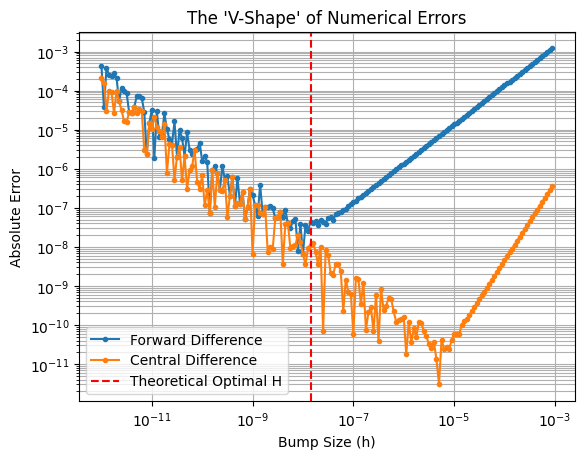

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# The original function: f(x) = e^x
def target_function(x):
    return np.exp(x)

# The analytical (exact) first derivative: f'(x) = e^x
def exact_first_derivative(x):
    return np.exp(x)

# The analytical (exact) second derivative: f''(x) = e^x
def exact_second_derivative(x):
    return np.exp(x)

# Settings
x_point = 1.0
machine_precision = 1e-16 # Standard 64-bit float precision

# Generate a wide range of "Bump Sizes" (h) from 10^-12 to 10^-3
bump_sizes = 10.**np.arange(-12.0, -3.0, 0.05)

# 1. Forward Difference Method: (f(x+h) - f(x)) / h
forward_diff = [(target_function(x_point + h) - target_function(x_point)) / h 
                for h in bump_sizes]

# 2. Central Difference Method: (f(x+h) - f(x-h)) / (2h)
# Note: This is usually more accurate because errors cancel out
central_diff = [0.5 * (target_function(x_point + h) - target_function(x_point - h)) / h 
                for h in bump_sizes]

# Calculate Absolute Errors
error_forward = np.abs(forward_diff - exact_first_derivative(x_point))
error_central = np.abs(central_diff - exact_first_derivative(x_point))

# Calculate the "Optimal Bump Size" mathematically
# This formula balances rounding error vs. truncation error
optimal_h = np.sqrt(2.0 * target_function(x_point) * machine_precision / exact_second_derivative(x_point))

# Plotting
plt.loglog(bump_sizes, error_forward, '.-', label="Forward Difference")
plt.loglog(bump_sizes, error_central, '.-', label="Central Difference")
plt.axvline(x=optimal_h, color='r', linestyle='--', label="Theoretical Optimal H")

plt.title("The 'V-Shape' of Numerical Errors")
plt.xlabel("Bump Size (h)")
plt.ylabel("Absolute Error")
plt.legend()
plt.grid(True, which="both", ls="-")
plt.show()